In [1]:
# Import thư viện
import cv2
import numpy as np
import os
import pickle
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from google.colab import drive

In [2]:
# Mount gg drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive//DATASET'

Mounted at /content/drive


In [3]:
# Khai báo đường dẫn
TRAIN_DIR  = os.path.join(DATASET_PATH, 'train')
VAL_DIR    = os.path.join(DATASET_PATH, 'val')
TEST_DIR   = os.path.join(DATASET_PATH, 'test')
OUTPUT_DIR = '/content/traditional'

In [34]:
# Khởi tạo ORB và BFMatcher
ORB = cv2.ORB_create(nfeatures=150)
BF = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
MAX_DESC_PER_CLASS = 3000
best_thresh = 50

In [5]:
def build_templates(train_dir):

    print("BUILDING ORB TEMPLATES")

    templates = {}

    # Khởi tạo ORB
    orb = cv2.ORB_create()

    for class_name in sorted(os.listdir(train_dir)):

        class_path = os.path.join(train_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        print(f"\nBuilding class: {class_name}")

        for side in ["truoc", "sau"]:

            side_path = os.path.join(class_path, side)

            if not os.path.isdir(side_path):
                continue

            template_name = f"{class_name}_{side}"
            all_descriptors = []

            for img_file in os.listdir(side_path):

                img_path = os.path.join(side_path, img_file)

                # check image load
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = cv2.resize(img, (224, 224))

                keypoints, descriptors = orb.detectAndCompute(img, None)

                if descriptors is not None:
                    all_descriptors.append(descriptors)

            # check empty
            if len(all_descriptors) == 0:
                continue

            combined_descriptors = np.vstack(all_descriptors)

            # Limit descriptors
            if combined_descriptors.shape[0] > MAX_DESC_PER_CLASS:

                idx = np.random.choice(
                    combined_descriptors.shape[0],
                    MAX_DESC_PER_CLASS,
                    replace=False
                )

                combined_descriptors = combined_descriptors[idx]

            templates[template_name] = combined_descriptors

            print(
                f"{template_name:15s}"
                f" -> {combined_descriptors.shape[0]} descriptors"
            )

    print("\nBUILD TEMPLATE COMPLETED")

    return templates

In [6]:
def predict_one(image_path, templates, distance_thresh):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return "unknown"

    img = cv2.resize(img, (224, 224))

    orb = cv2.ORB_create()

    keypoints, descriptors = orb.detectAndCompute(img, None)

    if descriptors is None:
        return "unknown"

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    scores = {}

    for class_name, template_descriptors in templates.items():

        if template_descriptors is None or len(template_descriptors) == 0:
            continue

        matches = bf.match(descriptors, template_descriptors)

        good_matches = [m for m in matches if m.distance < distance_thresh]

        scores[class_name] = len(good_matches)

    if len(scores) == 0:
        return "unknown"

    predicted_class = max(scores, key=scores.get)

    return predicted_class

In [7]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

def evaluate(dataset_dir,
             templates,
             distance_thresh,
             dataset_name):

    print(f"\n{dataset_name.upper()}\n")

    y_true = []
    y_pred = []

    # Duyệt từng class
    for class_name in sorted(os.listdir(dataset_dir)):

        class_path = os.path.join(
            dataset_dir,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        # Duyệt từng ảnh
        for img_file in os.listdir(class_path):

            img_path = os.path.join(
                class_path,
                img_file
            )

            # Predict
            pred_full = predict_one(
                img_path,
                templates,
                distance_thresh
            )

            # Bỏ _truoc / _sau
            pred = pred_full.split("_")[0]

            y_true.append(class_name)
            y_pred.append(pred)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    print(
        f"ACCURACY TRÊN TẬP "
        f"{dataset_name.upper()}: "
        f"{acc:.2%}"
    )

    print("\nBÁO CÁO CHI TIẾT:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return acc

In [8]:
def tune_threshold(val_dir, templates):

    thresholds = [30, 40, 50, 60, 70, 80]

    best_thresh = None
    best_acc = 0

    print("\nTUNING THRESHOLD...\n")

    for thresh in thresholds:

        acc = evaluate(
            val_dir,
            templates,
            thresh,
            f"VAL - THRESH {thresh}"
        )

        print(
            f"\nThreshold = {thresh}"
            f" -> Accuracy = {acc:.2%}"
        )

        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    print("\n")
    print(f"Best Threshold : {best_thresh}")
    print(f"Best Accuracy  : {best_acc:.2%}")

    return best_thresh

In [9]:
def save_templates(templates):

    save_path = os.path.join(
        OUTPUT_DIR,
        "orb_model.pkl"
    )

    with open(save_path, "wb") as f:
        pickle.dump(templates, f)

    print(f"\nSaved model -> {save_path}")


In [32]:
import os, pickle

# Tạo lại thư mục
os.makedirs('/content/traditional', exist_ok=True)

# Lưu local
with open('/content/traditional/orb_money_model.pkl', 'wb') as f:
    pickle.dump(templates, f)
print("Saved local")

Saved local


In [11]:
    # Build template
templates = build_templates(TRAIN_DIR)

    # Lưu vào file .pkl
    model_path = os.path.join(
        OUTPUT_DIR,
        "orb_money_model.pkl"
    )

    with open(model_path, "wb") as f:
        pickle.dump(templates, f)

    print(f"\nĐã lưu model tại: {model_path}")

BUILDING ORB TEMPLATES

Building class: 000200
000200_truoc    -> 3000 descriptors
000200_sau      -> 3000 descriptors

Building class: 000500
000500_truoc    -> 3000 descriptors
000500_sau      -> 3000 descriptors

Building class: 001000
001000_truoc    -> 3000 descriptors
001000_sau      -> 3000 descriptors

Building class: 002000
002000_truoc    -> 3000 descriptors
002000_sau      -> 3000 descriptors

Building class: 005000
005000_truoc    -> 3000 descriptors
005000_sau      -> 3000 descriptors

Building class: 010000
010000_truoc    -> 3000 descriptors
010000_sau      -> 3000 descriptors

Building class: 020000
020000_truoc    -> 3000 descriptors
020000_sau      -> 3000 descriptors

Building class: 050000
050000_truoc    -> 3000 descriptors
050000_sau      -> 3000 descriptors

Building class: 100000
100000_truoc    -> 3000 descriptors
100000_sau      -> 3000 descriptors

Building class: 200000
200000_truoc    -> 3000 descriptors
200000_sau      -> 3000 descriptors

Building class: 

In [18]:
print(TEST_DIR)
print(os.listdir(TEST_DIR))

/content/drive/MyDrive//DATASET/test
['100000', '005000', '500000', '010000', '200000', '020000', '050000', '002000', '001000', '000200', '000500']


In [35]:
test_acc = evaluate(
    TEST_DIR,
    templates,
    best_thresh,
    "TEST"
)


EVALUATE — TEST SET  (threshold=50)
  [000200_sau]  15/ 18 → 83.33% Check
  [000200_truoc]  19/ 22 → 86.36% Check
  [000500_sau]  11/ 12 → 91.67% Stable
  [000500_truoc]  11/ 12 → 91.67% Stable
  [001000_sau]   8/  9 → 88.89% Check
  [001000_truoc]  19/ 19 → 100.00% Stable
  [002000_sau]  18/ 24 → 75.00% Check
  [002000_truoc]  16/ 18 → 88.89% Check
  [005000_sau]  11/ 11 → 100.00% Stable
  [005000_truoc]   5/  5 → 100.00% Stable
  [010000_sau]  74/ 75 → 98.67% Stable
  [010000_truoc] 136/148 → 91.89% Stable
  [020000_sau]  30/ 37 → 81.08% Check
  [020000_truoc]  31/ 35 → 88.57% Check
  [050000_sau]  26/ 26 → 100.00% Stable
  [050000_truoc]  27/ 36 → 75.00% Check
  [100000_sau]  22/ 22 → 100.00% Stable
  [100000_truoc]  12/ 13 → 92.31% Stable
  [200000_sau]   7/  8 → 87.50% Check
  [200000_truoc]  18/ 19 → 94.74% Stable
  [500000_sau]  16/ 19 → 84.21% Check
  [500000_truoc]   1/  2 → 50.00% Check

───────────────────────────────────────────────────────
Accuracy (TEST): 90.34%
────────

In [26]:
import pickle
with open('/content/traditional/orb_money_model.pkl', 'rb') as f:
    templates = pickle.load(f)
print(f"Loaded {len(templates)} classes:", list(templates.keys())[:4])

Loaded 22 classes: ['000200_truoc', '000200_sau', '000500_truoc', '000500_sau']


In [27]:
def evaluate(dataset_dir, templates, distance_thresh, split_name="val"):
    print(f"\n{'='*55}")
    print(f"EVALUATE — {split_name.upper()} SET  (threshold={distance_thresh})")
    print(f"{'='*55}")

    y_true, y_pred, results = [], [], []

    for class_name in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for subfolder in sorted(os.listdir(class_path)):
            sub_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(sub_path):
                continue

            # Nhãn đúng
            true_label     = f"{class_name}_{subfolder}"
            correct, total = 0, 0

            for img_file in sorted(os.listdir(sub_path)):
                path = os.path.join(sub_path, img_file)
                if not os.path.isfile(path):
                    continue

                # Dự đoán
                pred = predict_one(path, templates, distance_thresh)
                ok   = (pred == true_label)

                correct += int(ok)
                total   += 1
                y_true.append(true_label)
                y_pred.append(pred)
                results.append({
                    "image" : path,
                    "true"  : true_label,
                    "pred"  : pred,
                    "correct": ok
                })

            class_acc = correct / total if total > 0 else 0
            print(f"  [{true_label}] {correct:3d}/{total:3d} → "
                  f"{class_acc:.2%} {'Stable' if class_acc >= 0.9 else 'Check'}")

    # Tổng kết
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'─'*55}")
    print(f"Accuracy ({split_name}): {acc:.2%}")
    print(f"{'─'*55}")
    print(classification_report(y_true, y_pred, zero_division=0))

    return y_true, y_pred, results, acc

In [36]:
y_true_val, y_pred_val, results_val, val_acc = evaluate(
    VAL_DIR, templates, best_thresh, "val"
)

y_true_test, y_pred_test, results_test, test_acc = evaluate(
    TEST_DIR, templates, best_thresh, "test"
)


EVALUATE — VAL SET  (threshold=50)
  [000200_sau]   0/ 15 → 0.00% Check
  [000200_truoc]   3/ 15 → 20.00% Check
  [000500_sau]  14/ 15 → 93.33% Stable
  [000500_truoc]  13/ 15 → 86.67% Check
  [001000_sau]  11/ 15 → 73.33% Check
  [001000_truoc]  13/ 15 → 86.67% Check
  [002000_sau]  12/ 15 → 80.00% Check
  [002000_truoc]  15/ 15 → 100.00% Stable
  [005000_sau]  15/ 15 → 100.00% Stable
  [005000_truoc]  15/ 15 → 100.00% Stable
  [010000_sau]  15/ 15 → 100.00% Stable
  [010000_truoc]  15/ 15 → 100.00% Stable
  [020000_sau]  15/ 15 → 100.00% Stable
  [020000_truoc]  15/ 15 → 100.00% Stable
  [050000_sau]  13/ 15 → 86.67% Check
  [050000_truoc]  15/ 15 → 100.00% Stable
  [100000_sau]  15/ 15 → 100.00% Stable
  [100000_truoc]  14/ 15 → 93.33% Stable
  [200000_sau]  14/ 15 → 93.33% Stable
  [200000_truoc]  15/ 15 → 100.00% Stable
  [500000_sau]  15/ 15 → 100.00% Stable
  [500000_truoc]   9/ 15 → 60.00% Check

───────────────────────────────────────────────────────
Accuracy (val): 85.15%
──

In [29]:
def plot_val_test_accuracy(val_acc, test_acc,
                           save_path='/content/traditional/01_val_test_acc.png'):
    diff   = abs(val_acc - test_acc)
    stable = diff <= 0.05

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')
    ax.tick_params(colors='black')

    labels = ['Val Accuracy', 'Test Accuracy']
    values = [val_acc, test_acc]
    colors = ['#4C9BE8', '#2EAA5E']

    bars = ax.bar(labels, values, color=colors, width=0.4,
                  zorder=3, edgecolor='none')
    ax.set_ylim(0, 1.18)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0, linewidth=0.5)
    ax.set_ylabel('Accuracy', color='black', fontsize=12)
    ax.set_title('Val vs Test Accuracy', color='black',
                 fontsize=14, fontweight='bold', pad=14)

    # Giá trị trên cột
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.025,
                f'{val:.2%}',
                ha='center', va='bottom',
                color='black', fontsize=13, fontweight='bold')

    # Nhãn chênh lệch

    ax.text(0.5, 0.08,
            f'Chênh lệch: {diff:.2%}',
            ha='center', transform=ax.transAxes,
            color='#b07800', fontsize=11)

    ax.xaxis.label.set_color('black')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {save_path}')

In [37]:
def plot_f1_per_class(y_true, y_pred,
                      save_path='/content/traditional/02_f1_per_class.png'):
    classes = sorted(list(set(y_true) | set(y_pred)))
    report  = classification_report(
        y_true, y_pred,
        labels=classes, target_names=classes,
        output_dict=True, zero_division=0
    )

    # Gộp lại sau đó tính F1 trung bình theo mệnh giá
    from collections import defaultdict
    f1_by_class = defaultdict(list)
    for c in classes:
        if c == 'unknown':
            continue
        # Tách phần mệnh giá, bỏ trước sau
        base = c.rsplit('_', 1)[0] if '_' in c else c
        f1_by_class[base].append(report[c]['f1-score'])

    chart_cls = sorted(f1_by_class.keys())
    f1s       = [sum(f1_by_class[c]) / len(f1_by_class[c]) for c in chart_cls]

    bar_cols = ['#2EAA5E' if f >= 0.9 else
                '#E8A020' if f >= 0.75 else
                '#E05040' for f in f1s]

    fig, ax = plt.subplots(figsize=(9, max(5, len(chart_cls) * 0.45)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')
    ax.tick_params(colors='black')

    bars = ax.barh(chart_cls, f1s, color=bar_cols,
                   zorder=3, edgecolor='none')
    ax.set_xlim(0, 1.18)
    ax.xaxis.grid(True, color='#eeeeee', zorder=0, linewidth=0.5)


    ax.set_xlabel('F1-score', color='black', fontsize=12)
    ax.set_title('F1-score theo từng class (Test set)',
                 color='black', fontsize=14, fontweight='bold', pad=14)
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

    for bar, val in zip(bars, f1s):
        ax.text(val + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}',
                va='center', color='black', fontsize=9)

    legend_patches = [
        mpatches.Patch(color='#2EAA5E', label='F1 ≥ 0.90'),
        mpatches.Patch(color='#E8A020', label='F1 ≥ 0.75'),
        mpatches.Patch(color='#E05040', label='F1 < 0.75'),
    ]
    ax.legend(handles=legend_patches, loc='lower right',
              facecolor='white', edgecolor='#cccccc',
              labelcolor='black', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {save_path}')


In [38]:
def plot_confusion_matrix(y_true, y_pred,
                          by_side=True,
                          save_path='/content/traditional/03_confusion_matrix.png'):
    """
    by_side=False → gộp truoc/sau, hiển thị 11 class theo mệnh giá
    by_side=True  → tách truoc/sau, hiển thị 22 class
    """
    if not by_side:
        # Gộp lại
        y_true = [y.rsplit('_', 1)[0] if '_' in y else y for y in y_true]
        y_pred = [y.rsplit('_', 1)[0] if '_' in y else y for y in y_pred]
    classes = sorted(list(set(y_true) | set(y_pred)))
    cm      = confusion_matrix(y_true, y_pred, labels=classes)
    n       = len(classes)

    fig_size = max(8, n * 0.7)
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size * 0.85))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
        linewidths=0.4,
        linecolor='#dddddd',
        annot_kws={'size': max(7, 11 - n // 4), 'color': 'black'}
    )

    title_suffix = 'theo mặt truoc/sau' if by_side else 'theo mệnh giá'
    ax.set_title(f'Confusion Matrix — {title_suffix} (Test set)',
                 color='black', fontsize=14,
                 fontweight='bold', pad=14)
    ax.set_xlabel('Predicted', color='black', fontsize=12)
    ax.set_ylabel('True',      color='black', fontsize=12)
    ax.tick_params(axis='x', rotation=45, colors='black',
                   labelsize=max(7, 10 - n // 5))
    ax.tick_params(axis='y', rotation=0,  colors='black',
                   labelsize=max(7, 10 - n // 5))

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors='black')
    cbar.ax.yaxis.label.set_color('black')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {save_path}')

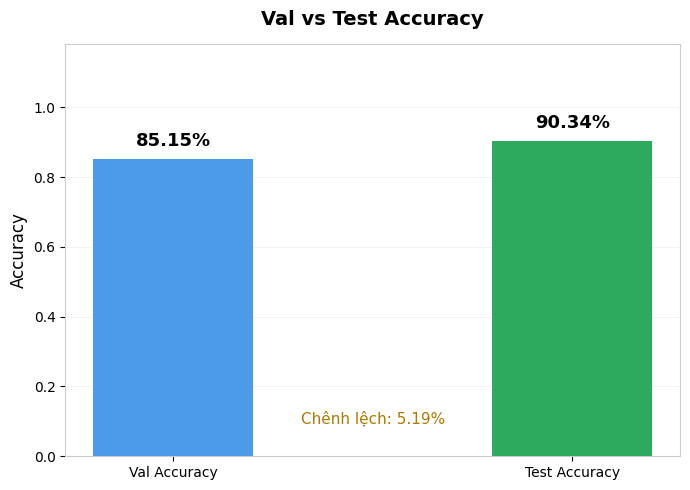

Saved → /content/traditional/01_val_test_acc.png


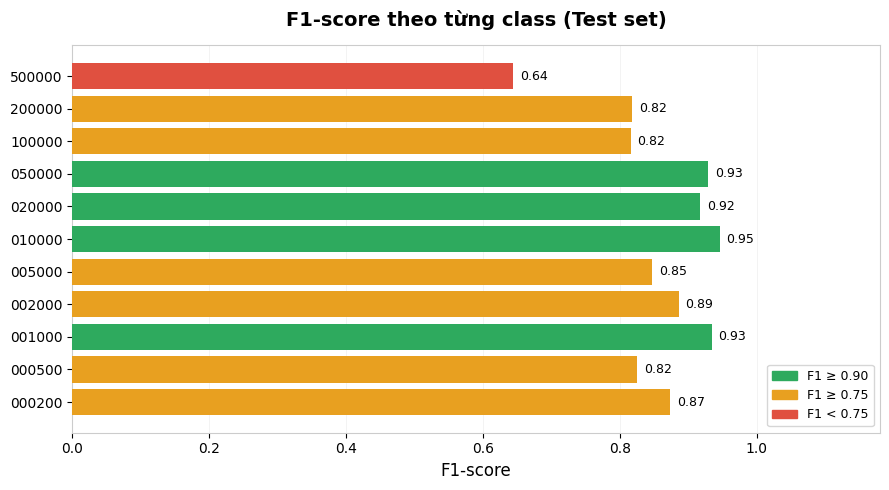

Saved → /content/traditional/02_f1_per_class.png


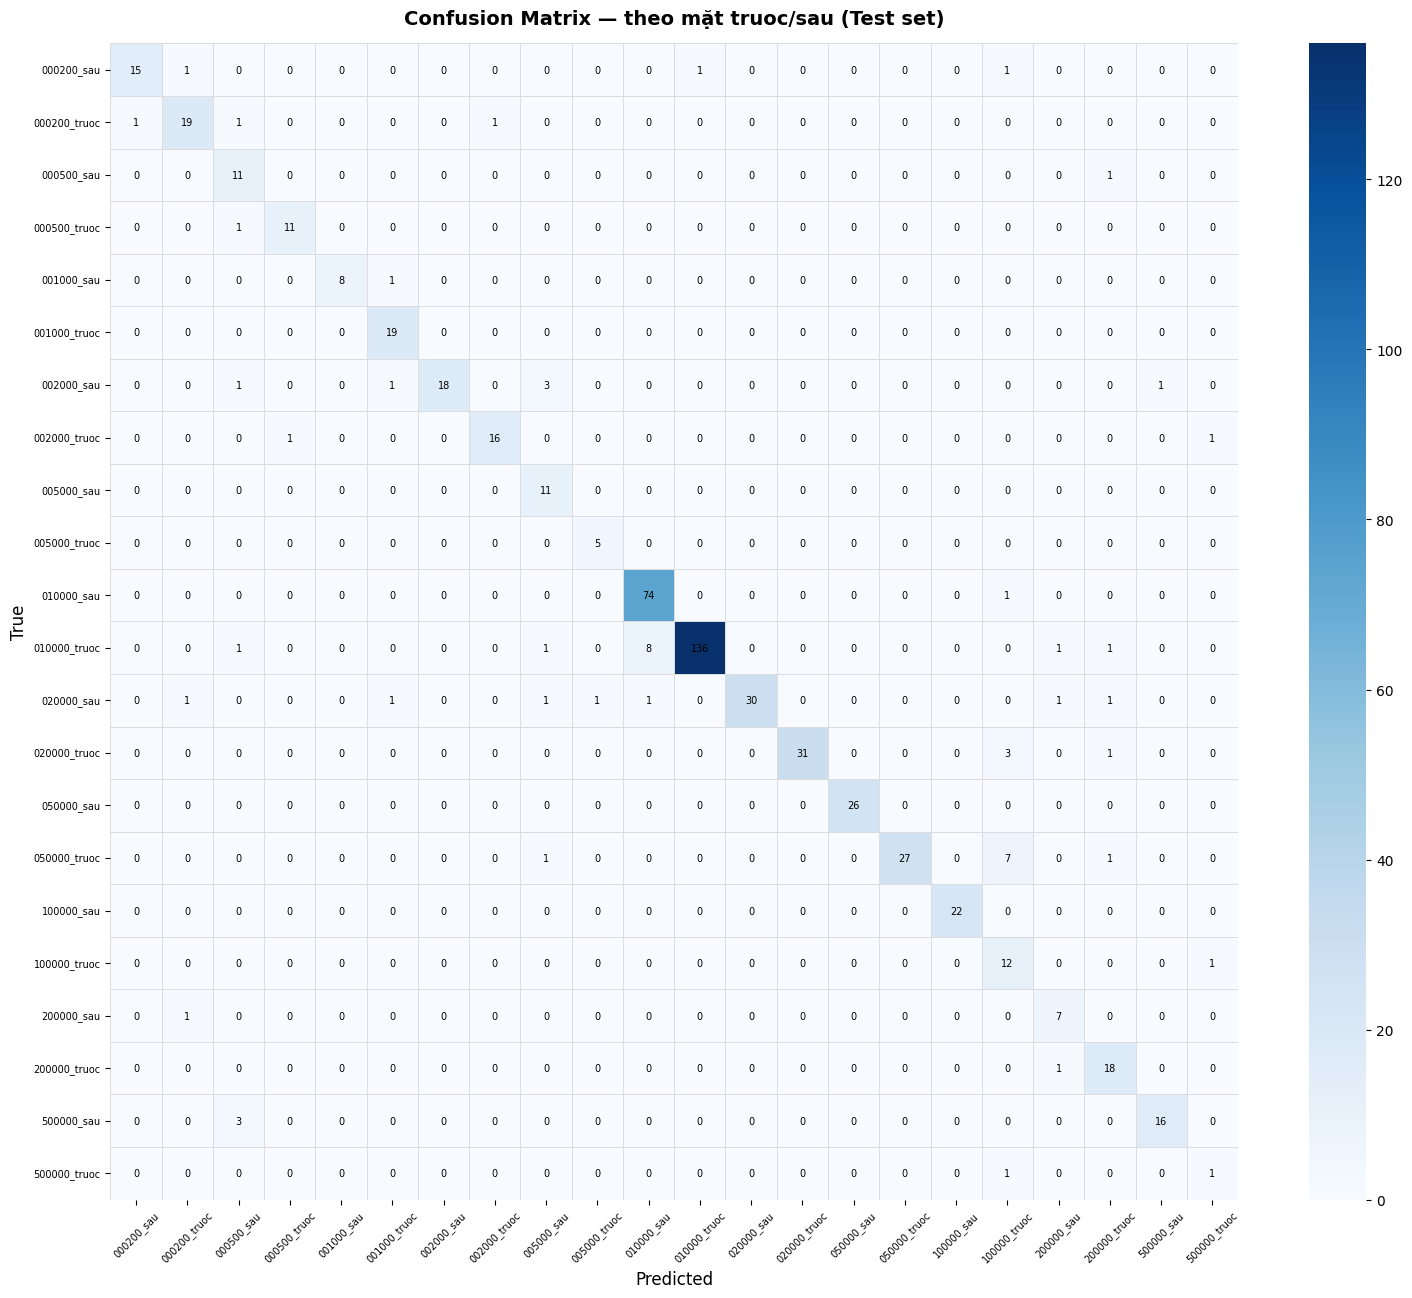

Saved → /content/traditional/03_confusion_matrix.png


In [39]:
plot_val_test_accuracy(val_acc, test_acc)
plot_f1_per_class(y_true_test, y_pred_test)
plot_confusion_matrix(y_true_test, y_pred_test)